# 0.Library

In [105]:
# general
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import importlib

# Paths
import sys
sys.path.append('../') 
from features import data_utils as du
from features import data_pipeline as dp
from features import general_func as gf
import constants_data as cd
import paths_data as paths
from features import model_utils as mu

# Reload
importlib.reload(du)
importlib.reload(dp)
importlib.reload(gf)
importlib.reload(cd)
importlib.reload(paths)
importlib.reload(mu)

<module 'features.model_utils' from '/home/smira/myproject/detection_AD_with_VR_data/src/notebooks/../features/model_utils.py'>

# 1. Paths and Constants

In [106]:
# path and name input
df_name_input = "cleaned_features_20_young_patients.csv"
df_path = paths.STAGE_THREE_DATA_PREPROCESSING / df_name_input

result_md_name_input = "3.overfitting_score_13patients.md"
result_md_path = paths.RESULTS_DIR / result_md_name_input

# path and name output
output_name = ""
output_name_directory = paths.RESULTS_DIR / output_name

In [107]:
all_results = du.read_readme_tables(result_md_path)
all_results.head()

,Model,Train MSE,Test MSE,Gap,Overfitting,Experiment
0,LinearRegression,0.00,10.036,10.036,Yes,Experiment 1: All 120 Features + Models
1,Ridge,0.00,10.020,10.020,Yes,Experiment 1: All 120 Features + Models
2,RandomForestRegressor,1.00,10.366,9.367,Yes,Experiment 1: All 120 Features + Models
3,XGBRegressor,0.00,25.60,25.60,**Severe**,Experiment 1: All 120 Features + Models
4,SVR,7.20,11.01,3.81,Low,Experiment 1: All 120 Features + Models


In [108]:
numeric_columns = ["Train MSE", "Test MSE", "Gap"]
all_results     = du.convert_columns_to_numerical(all_results, numeric_columns)

In [109]:
all_results.dtypes

Model           object
Train MSE      float64
Test MSE       float64
Gap            float64
Overfitting     object
Experiment      object
dtype: object

# Method 1: comparing MSE mean of all models for each feature selection

In [110]:
mean_models_MSE_dict = cd.mean_models_MSE_dict
mean_models_MSE_dict["All 120 Features"] = round(all_results[(all_results['Experiment'] == 'Experiment 1: All 120 Features + Models')]['Test MSE'].mean(), 2)
mean_models_MSE_dict["SelectKBest (50 Features)"] = round(all_results[(all_results['Experiment'] == 'Experiment 1: All 120 Features + Models')]['Test MSE'].mean(), 2)
mean_models_MSE_dict["SelectKBest (20 Features)"] = round(all_results[(all_results['Experiment'] == 'Experiment 2: SelectKBest (50 Features) + Models')]['Test MSE'].mean(), 2)
mean_models_MSE_dict["SelectKBest (10 Features)"] = None
mean_models_MSE_dict["Variance threshold"] = None
mean_models_MSE_dict["PCA (5 Components)"] = round(all_results[(all_results['Experiment'] == 'Experiment 4: PCA (5 Components) + Models')]['Test MSE'].mean(), 2)

In [111]:
mean_models_MSE_dict

{'All 120 Features': np.float64(13.22),
 'SelectKBest (50 Features)': np.float64(13.22),
 'SelectKBest (20 Features)': np.float64(13.45),
 'SelectKBest (10 Features)': None,
 'RFECV': None,
 'Variance threshold': None,
 'PCA (5 Components)': np.float64(10.02)}

In [112]:
mean_models_MSE_df = pd.DataFrame(mean_models_MSE_dict.items(), columns=['Method', 'MSE Mean']).round(3)
mean_models_MSE_df

,Method,MSE Mean
0,All 120 Features,13.22
1,SelectKBest (50 Features),13.22
2,SelectKBest (20 Features),13.45
3,SelectKBest (10 Features),NaN
4,RFECV,NaN
5,Variance threshold,NaN
6,PCA (5 Components),10.02


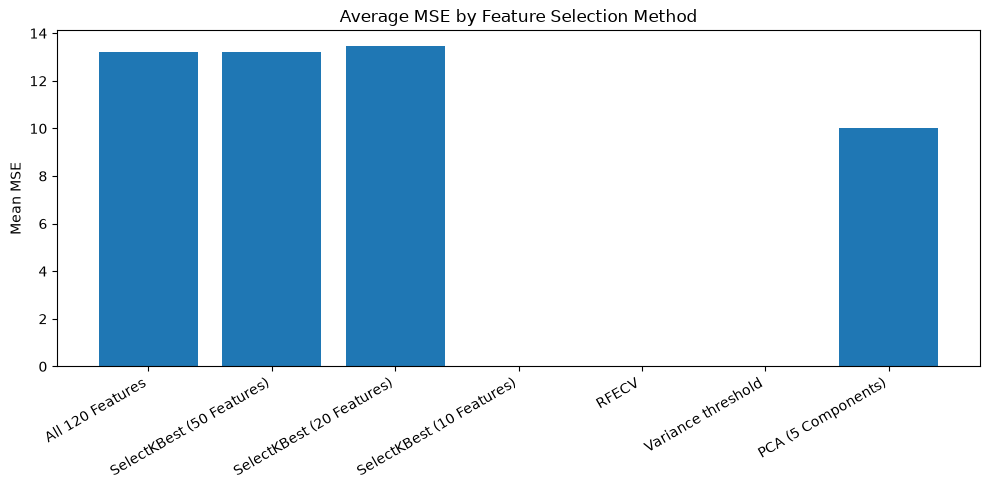

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(mean_models_MSE_df["Method"], mean_models_MSE_df["MSE Mean"])

plt.ylabel("Mean MSE")
plt.title("Average MSE by Feature Selection Method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

# Method 2: comparing overfitting mean of all models for each feature selection

In [114]:
mean_models_overfitting_dict = cd.mean_models_overfitting_dict
mean_models_overfitting_dict["All 120 Features"] = round(all_results[(all_results['Experiment'] == 'Experiment 1: All 120 Features + Models')]['Gap'].mean(), 2)
mean_models_overfitting_dict["SelectKBest (50 Features)"] = round(all_results[(all_results['Experiment'] == 'Experiment 1: All 120 Features + Models')]['Gap'].mean(), 2)
mean_models_overfitting_dict["SelectKBest (20 Features)"] = round(all_results[(all_results['Experiment'] == 'Experiment 2: SelectKBest (50 Features) + Models')]['Gap'].mean(), 2)
mean_models_overfitting_dict["SelectKBest (10 Features)"] = None
mean_models_overfitting_dict["Variance threshold"] = None
mean_models_overfitting_dict["PCA (5 Components)"] = round(all_results[(all_results['Experiment'] == 'Experiment 4: PCA (5 Components) + Models')]['Gap'].mean(), 2)

In [115]:
mean_models_overfitting_df = pd.DataFrame(mean_models_overfitting_dict.items(), columns=['Method', 'overfitting Mean']).round(3)
mean_models_overfitting_df

,Method,overfitting Mean
0,All 120 Features,11.53
1,SelectKBest (50 Features),11.53
2,SelectKBest (20 Features),11.83
3,SelectKBest (10 Features),NaN
4,RFECV,NaN
5,Variance threshold,NaN
6,PCA (5 Components),7.49


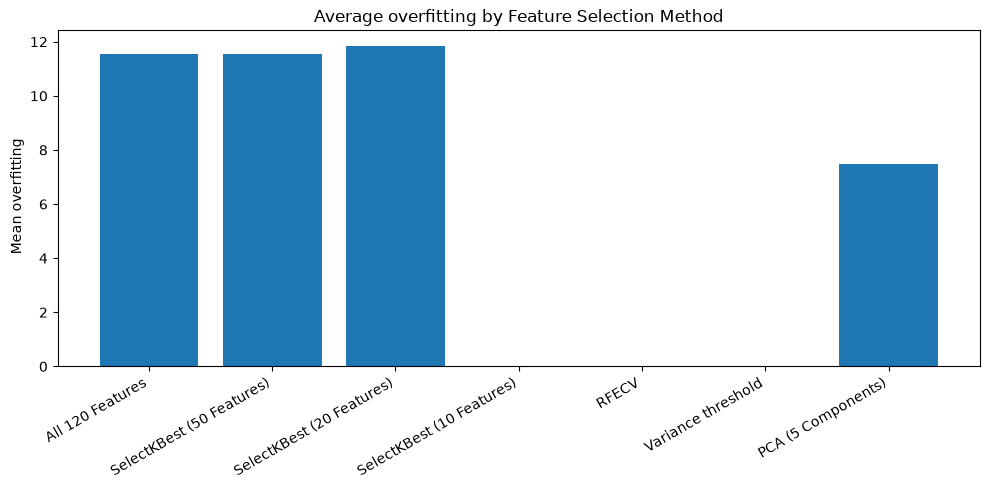

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(mean_models_overfitting_df["Method"], mean_models_overfitting_df["overfitting Mean"])

plt.ylabel(" Mean overfitting")
plt.title("Average overfitting by Feature Selection Method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

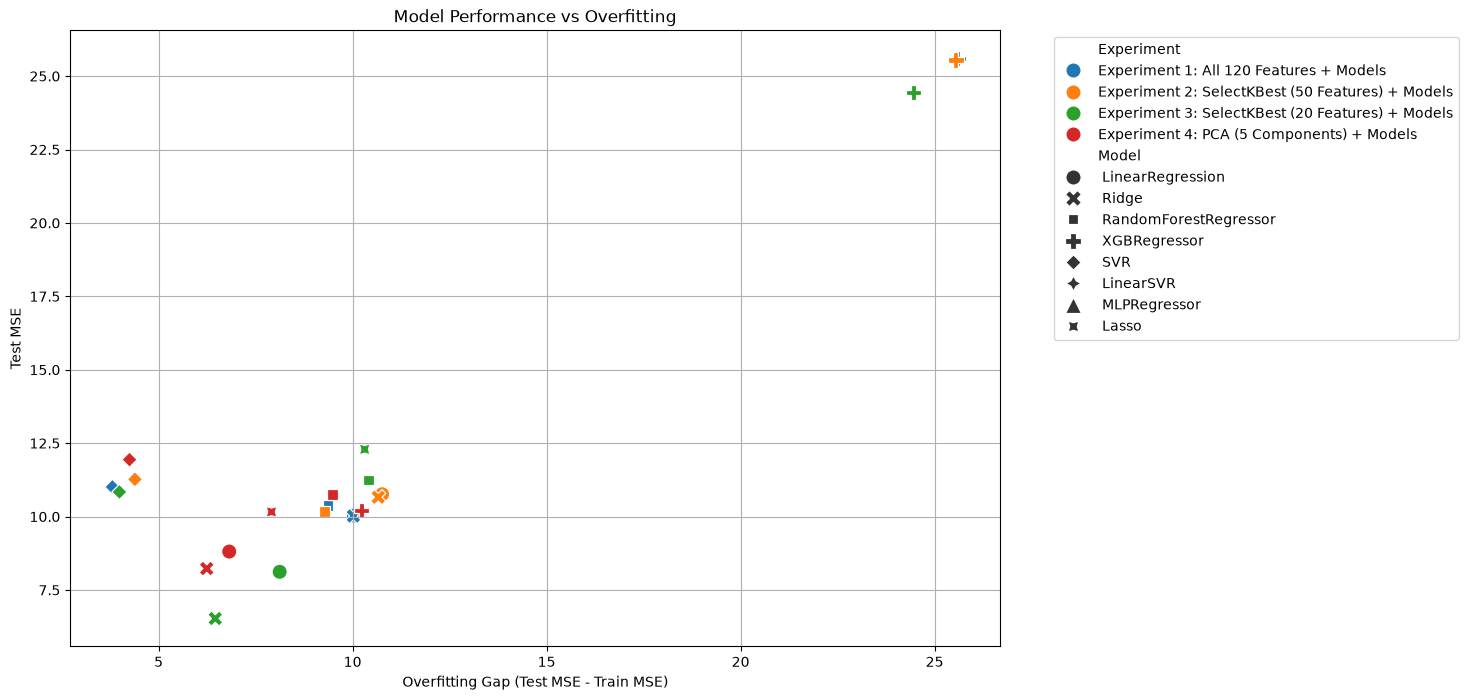

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=all_results,
    x="Gap",
    y="Test MSE",
    hue="Experiment",   # color by feature selection
    style="Model",      # marker by model
    s=120
)

plt.xlabel("Overfitting Gap (Test MSE - Train MSE)")
plt.ylabel("Test MSE")
plt.title("Model Performance vs Overfitting")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

# Method 3: Heatmap

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

mse_table = all_results.pivot(
    index="Experiment",
    columns="Model",
    values="Test MSE"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    mse_table,
    annot=True,
    fmt=".2f"
)

plt.title("Test MSE Comparison")
plt.xlabel("Model")
plt.ylabel("Feature Selection Method")

plt.show()

In [ ]:
gap_table = all_results.pivot(
    index="Experiment",
    columns="Model",
    values="Gap"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    gap_table,
    annot=True,
    fmt=".2f"
)

plt.title("Overfitting Gap Comparison")
plt.xlabel("Model")
plt.ylabel("Feature Selection Method")

plt.show()

In [11]:
df_heatmap = MSE_models_feature_selection_methods.drop(columns=["Best Method", "Best MSE"])

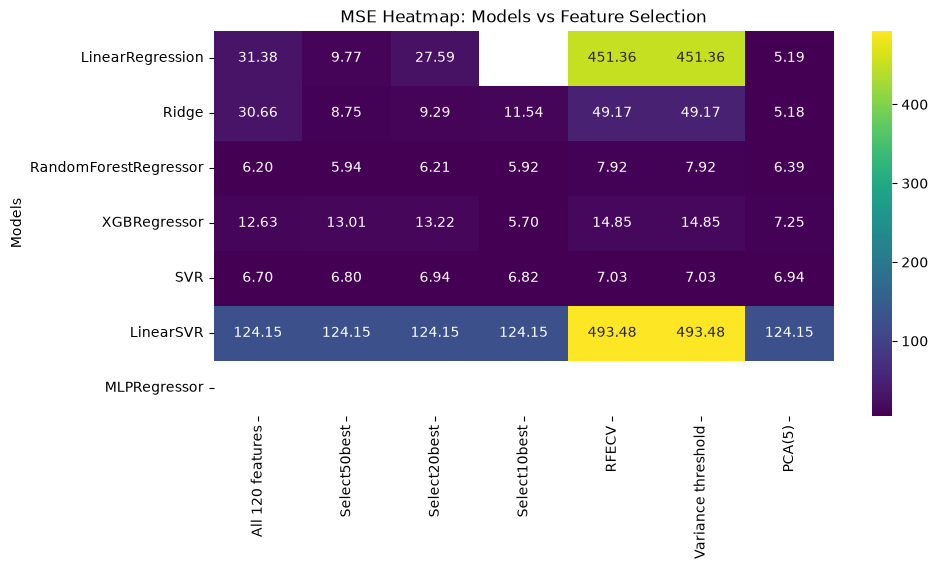

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    df_heatmap.set_index("Models"),
    annot=True,   # show values
    fmt=".2f",    # format numbers
    cmap="viridis"  # color style
)

plt.title("MSE Heatmap: Models vs Feature Selection")
plt.show()

# Comparing Target value of 20 young patients without any True MoCA score

In [5]:
# Constants and paths
parent_folder = Path("../..") # go 2 folder up= "../.."
df_path = parent_folder / "data" / "produced_csv" / "4.cleaned_features_20_young_patients_with_target.csv"

preprocessing_folder = parent_folder / "preoduced_csv"

df = pd.read_csv(df_path)

df['Predicted_MoCA']

0     27.152127
1     27.098029
2     27.182443
3     27.100001
4     27.142757
5     27.209877
6     27.229576
7     27.135715
8     27.149004
9     27.124110
10    27.252069
11    27.120115
12    27.088818
13    27.087835
14    27.088628
15    27.088413
16    27.114723
17    27.089856
18    27.274613
19    27.187302
Name: Predicted_MoCA, dtype: float64

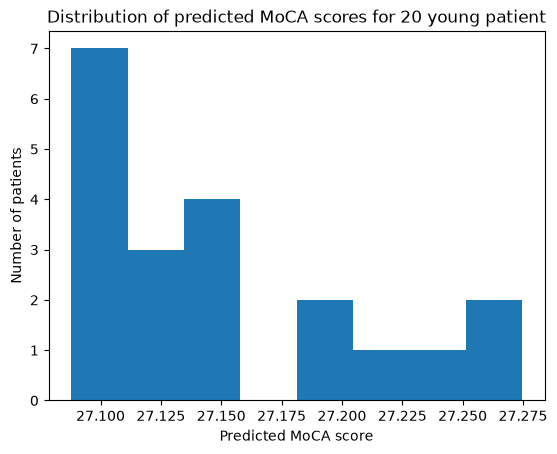

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['Predicted_MoCA'], bins=8)
plt.xlabel("Predicted MoCA score")
plt.ylabel("Number of patients")
plt.title("Distribution of predicted MoCA scores for 20 young patient")
plt.show()